### **1. Project Objective**

---

**Business Goal**  
How can we forecast weekly sales by store and department to improve inventory planning, staffing, markdown strategy, and holiday readiness?

---

**Key Business Questions**
1. Which stores and departments drive the highest sales?
2. How do holidays affect weekly sales?
3. Do markdown promotions increase sales?
4. Which economic factors correlate with sales?
5. Can we forecast future weekly sales accurately enough for planning?

---

**Prediction Target:** `Weekly_Sales`

**Granularity:** Store + Department + Week

### **2.Import Libraries**

In [21]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import os
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../src"))
from data.loader import load_full_data

### **3. Define Project Paths**

In [3]:
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"

### **4. Load Raw Datasets**

In [4]:
train = pd.read_csv(DATA_RAW / "train.csv")
test = pd.read_csv(DATA_RAW / "test.csv")
features = pd.read_csv(DATA_RAW / "features.csv")
stores = pd.read_csv(DATA_RAW / "stores.csv")

### **5. Raw Dataset Overview**

In [5]:
datasets = {
    "train": train,
    "test": test,
    "features": features,
    "stores": stores,
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("Shape:", df.shape)
    display(df.head())
    print("Columns:", df.columns.tolist())


TRAIN
Shape: (421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

TEST
Shape: (115064, 4)


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


Columns: ['Store', 'Dept', 'Date', 'IsHoliday']

FEATURES
Shape: (8190, 12)


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


Columns: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

STORES
Shape: (45, 3)


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


Columns: ['Store', 'Type', 'Size']


### **6. Dataset Column Understanding**

#### **1. Features.csv**
This file contains additional information about the stores, such as weather and economic data.

| Column Name   | Description                                                                 |
|---------------|-----------------------------------------------------------------------------|
| Store         | Unique identifier for each store.                                          |
| Date          | The date of the observation.                                               |
| Temperature   | Average temperature in the region (in Fahrenheit).                        |
| Fuel_Price    | Cost of fuel in the region (per gallon).                                   |
| MarkDown1-5   | Data related to promotional markdowns. May contain missing values (NA).    |
| CPI           | Consumer Price Index, an economic indicator.                              |
| Unemployment  | Unemployment rate in the region.                                           |
| IsHoliday     | Boolean indicating whether the week includes a special holiday.            |

---

#### **2. Stores.csv**
This file contains metadata about each store.

| Column Name   | Description                                                                 |
|---------------|-----------------------------------------------------------------------------|
| Store         | Unique identifier for each store.                                          |
| Type          | Type of store (e.g., A, B, C).                                             |
| Size          | Square footage of the store.                                               |

---

#### **3. Train.csv**
This file contains historical sales data for training the model.

| Column Name   | Description                                                                 |
|---------------|-----------------------------------------------------------------------------|
| Store         | Unique identifier for each store.                                          |
| Dept          | Unique identifier for each department within a store.                      |
| Date          | The date of the observation.                                               |
| Weekly_Sales  | Sales for the given store, department, and date.                           |
| IsHoliday     | Boolean indicating whether the week includes a special holiday.            |

---

#### **4. Test.csv**
This file contains the test dataset for which predictions are to be made.

| Column Name   | Description                                                                 |
|---------------|-----------------------------------------------------------------------------|
| Store         | Unique identifier for each store.                                          |
| Dept          | Unique identifier for each department within a store.                      |
| Date          | The date of the observation.                                               |
| IsHoliday     | Boolean indicating whether the week includes a special holiday.            |

### **7. Missing Values Check**

In [6]:
for name, df in datasets.items():
    print(f"\n{name.upper()} Missing Values")
    display(df.isnull().sum().to_frame("missing_count"))


TRAIN Missing Values


,missing_count
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0



TEST Missing Values


,missing_count
Store,0
Dept,0
Date,0
IsHoliday,0



FEATURES Missing Values


,missing_count
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,4158
MarkDown2,5269
MarkDown3,4577
MarkDown4,4726
MarkDown5,4140
CPI,585



STORES Missing Values


,missing_count
Store,0
Type,0
Size,0


### **8. Duplicate Check**

In [7]:
for name, df in datasets.items():
    print(f"{name} duplicates:", df.duplicated().sum())

train duplicates: 0
test duplicates: 0
features duplicates: 0
stores duplicates: 0


### **9. Date Range Check**

In [8]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])
features["Date"] = pd.to_datetime(features["Date"])

print("Train date range:", train["Date"].min(), "to", train["Date"].max())
print("Total Days:", (train["Date"].max() - train["Date"].min()).days)

print("Test date range:", test["Date"].min(), "to", test["Date"].max())
print("Total Days:", (test["Date"].max() - test["Date"].min()).days)

print("Features date range:", features["Date"].min(), "to", features["Date"].max())
print("Total Days:", (features["Date"].max() - features["Date"].min()).days)

Train date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Total Days: 994
Test date range: 2012-11-02 00:00:00 to 2013-07-26 00:00:00
Total Days: 266
Features date range: 2010-02-05 00:00:00 to 2013-07-26 00:00:00
Total Days: 1267


**The training data spans from 2010 to 2012, while test data contains future dates. This confirms a time-based forecasting problem.**

### **10. Target Variable Understanding**

In [9]:
train["Weekly_Sales"].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

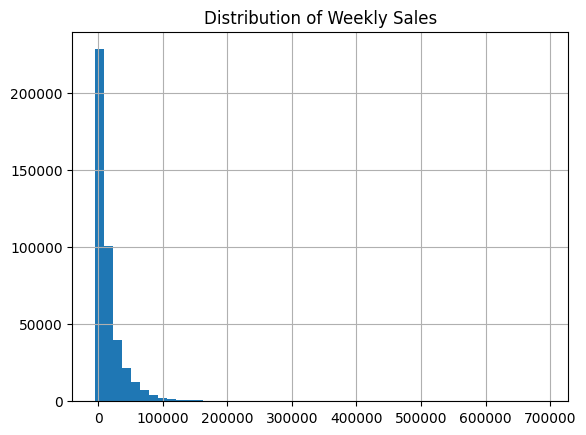

In [22]:
train["Weekly_Sales"].hist(bins=50)
plt.title("Distribution of Weekly Sales")
plt.show()

### **11. Basic Business Checks**

In [10]:
print("Unique stores:", train["Store"].nunique())
print("Unique departments:", train["Dept"].nunique())
print("Store types:", stores["Type"].unique())
print("Holiday rows:", train["IsHoliday"].sum())

Unique stores: 45
Unique departments: 81
Store types: <ArrowStringArray>
['A', 'B', 'C']
Length: 3, dtype: str
Holiday rows: 29661


In [11]:
train.groupby("IsHoliday")["Weekly_Sales"].agg(["count", "mean", "median", "sum"])

,count,mean,median,sum
IsHoliday,,,,
False,391909,15901.445069,7589.95,6.231919e+09
True,29661,17035.823187,7947.74,5.052996e+08


In [12]:
stores.groupby("Type")["Size"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
Type,,,,
A,22,177247.727273,39690,219622
B,17,101190.705882,34875,140167
C,6,40541.666667,39690,42988


In [23]:
train.groupby("IsHoliday")["Weekly_Sales"].mean()

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

**Holiday weeks show significantly higher average sales compared to non-holiday weeks, indicating demand spikes. This suggests the model should treat holidays as a separate signal rather than a regular feature.**

### **12. Validate Loader Script**

In [16]:
df = load_full_data()
print(df.head())
display(df.isnull().sum().to_frame("missing_count"))
print("Duplicates:", df.duplicated().sum())

INFO:root:Loading raw data...
INFO:root:Final dataset shape: (421570, 17)


   Store  Dept        Date  Weekly_Sales  IsHoliday_x  Temperature  \
0      1     1  2010-02-05      24924.50        False        42.31   
1      1     1  2010-02-12      46039.49         True        38.51   
2      1     1  2010-02-19      41595.55        False        39.93   
3      1     1  2010-02-26      19403.54        False        46.63   
4      1     1  2010-03-05      21827.90        False        46.50   

   Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
0       2.572        NaN        NaN        NaN        NaN        NaN   
1       2.548        NaN        NaN        NaN        NaN        NaN   
2       2.514        NaN        NaN        NaN        NaN        NaN   
3       2.561        NaN        NaN        NaN        NaN        NaN   
4       2.625        NaN        NaN        NaN        NaN        NaN   

          CPI  Unemployment  IsHoliday_y Type    Size  
0  211.096358         8.106        False    A  151315  
1  211.242170         8.106       

,missing_count
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday_x,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479


Duplicates: 0


In [19]:
print(set(train.columns) & set(features.columns))
print(set(train.columns) & set(stores.columns))

{'Store', 'IsHoliday', 'Date'}
{'Store'}


In [20]:
features.groupby(["Store", "Date", "IsHoliday"]).size().value_counts()
stores["Store"].value_counts()

Store
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    1
31    1
32    1
33    1
34    1
35    1
36    1
37    1
38    1
39    1
40    1
41    1
42    1
43    1
44    1
45    1
Name: count, dtype: int64

#### **Validation Insight**

The features dataset is uniquely identified by Store + Date + IsHoliday, and the stores dataset is uniquely identified by Store. This confirms that the selected merge keys will not introduce duplicate rows or data explosion.

### **13. Initial Business Observations**

- The target variable is `Weekly_Sales`.
- The prediction level is `Store + Dept + Date`.
- The train dataset contains historical sales, while the test dataset contains future store-department-week combinations.
- `features.csv` adds business and economic drivers such as temperature, fuel price, CPI, unemployment, holidays, and markdowns.
- `stores.csv` provides store-level attributes such as store type and size.
- Holiday weeks need special attention because retail sales behavior can change significantly around major holidays.
- Markdown fields have missing values, which likely means no markdown/promotion was active for those weeks.
- The loader script should be used later for repeatable data ingestion instead of manually merging in every notebook.